In [2]:
from helper import build_model, create_generators

In [18]:
import pandas as pd
train_df1 = pd.read_csv('csv_data/train_df_corrected.csv')
val_df1 = pd.read_csv('csv_data/val_df_corrected.csv')
train_df1

,filepath,filename,label,source,subfolder,hash,label_idx
0,data/FMD_DATASET/without_mask/simple/simple334...,simple3341.jpg,without_mask,dataset1_kaggle,simple,96286b38179d06efbb6bf6a65f492803,1
1,data/FMD_DATASET/incorrect_mask/mmc/1465.jpg,1465.jpg,mask_worn_incorrectly,dataset1_kaggle,mmc,36c8ebeb6f1e93e995349abcb86098e8,2
2,data/FMD_DATASET/incorrect_mask/mmc/923.jpg,923.jpg,mask_worn_incorrectly,dataset1_kaggle,mmc,72f16b119652cabeec9ebbe6b25173a7,2
3,data/FMD_DATASET/without_mask/simple/simple696...,simple696.jpg,without_mask,dataset1_kaggle,simple,752fea20108e4fbfeb0bdca684d1328d,1
4,data/FMD_DATASET/without_mask/simple/simple286...,simple2869.jpg,without_mask,dataset1_kaggle,simple,d33a69aa319892b421dc11e336b9b9ef,1
...,...,...,...,...,...,...,...
13092,data/face_data/bare_face/1 (2714).jpg,1 (2714).jpg,without_mask,dataset2_kaggle,bare_face,bc3c988fbe06c656faedc9f2069d7ff4,1
13093,data/FMD_DATASET/incorrect_mask/mc/172.jpg,172.jpg,mask_worn_incorrectly,dataset1_kaggle,mc,4dae33eac7cd1c3d61f831441abad4e4,2
13094,data/FMD_DATASET/without_mask/simple/simple177...,simple1772.jpg,without_mask,dataset1_kaggle,simple,cb9fe7f34c1495865f09ca03f59a31e5,1
13095,data/FMD_DATASET/without_mask/simple/simple475...,simple475.jpg,without_mask,dataset1_kaggle,simple,737472991c6c4552e713dd9ff4049767,1


In [39]:
train_df_small = train_df1.sample(frac=0.1, random_state=42)
train_df_small2 = train_df1.sample(frac=0.05, random_state=42)

train_df_small2

,filepath,filename,label,source,subfolder,hash,label_idx
10412,data/FMD_DATASET/with_mask/simple/simple2732.jpg,simple2732.jpg,with_mask,dataset1_kaggle,simple,d362efed65d2e491a434df17840973d3,0
8985,data/FMD_DATASET/incorrect_mask/mmc/805.jpg,805.jpg,mask_worn_incorrectly,dataset1_kaggle,mmc,e5983b7b8e273497a25d776580a87d4f,2
8741,data/FMD_DATASET/incorrect_mask/mc/1208.jpg,1208.jpg,mask_worn_incorrectly,dataset1_kaggle,mc,998a45e75e024d708ff787a6f6c1313b,2
1236,data/FMD_DATASET/without_mask/simple/simple42.jpg,simple42.jpg,without_mask,dataset1_kaggle,simple,cf5c3341957857dd676487f3e5a8be17,1
720,data/cifar_not_related/cifar_2082.jpg,cifar_2082.jpg,not_related,dataset3_cifar10,cifar_not_related,487a521e420cd3ef19e297aaa7348e1f,3
...,...,...,...,...,...,...,...
12314,data/FMD_DATASET/with_mask/simple/simple1699.jpg,simple1699.jpg,with_mask,dataset1_kaggle,simple,a9db8ef45c2d4fcc78a3f6f6fb360ee4,0
200,data/FMD_DATASET/with_mask/simple/simple3472.jpg,simple3472.jpg,with_mask,dataset1_kaggle,simple,f1ddc782a9c3ea0548d9c8acaff5cdff,0
6752,data/FMD_DATASET/without_mask/simple/simple106...,simple1069.jpg,without_mask,dataset1_kaggle,simple,ab85e03354a44dd28527ca68f485bdad,1
9176,data/FMD_DATASET/without_mask/simple/simple115...,simple1153.jpg,without_mask,dataset1_kaggle,simple,b4ab467bb611f56d742dfd5049fc505f,1


In [25]:
IMG_SIZE = (128, 128) 
BATCH_SIZE=64
NUM_CLASSES=4
LEARNING_RATE=0.0001
train_gen1, val_gen1 = create_generators(
    train_df=train_df_small,
    val_df=val_df1,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    use_augmentation=False
)

Found 1310 validated image filenames belonging to 4 classes.
Found 2806 validated image filenames belonging to 4 classes.


In [26]:
model1=build_model( input_shape=IMG_SIZE + (3,),
    num_classes=NUM_CLASSES,
    learning_rate=LEARNING_RATE,
    dropout_rate=0.2 )


I0000 00:00:1777923719.732349 3531069 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9931 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


Adding a Dropout layer with rate 0.2


In [27]:
model1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [29]:
from tensorflow.keras import callbacks
checkpoint_model1 = callbacks.ModelCheckpoint(
    filepath       = 'MODEL1_V2.keras',
    monitor        = 'val_accuracy',
    save_best_only = True,
    mode           = 'max',
    verbose        = 1
)
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [35]:
history_without_overfit = model1.fit(
    train_gen1,
    epochs=25,
    validation_data=val_gen1,
    callbacks=[checkpoint_model1,early_stop]
)

Epoch 1/25


I0000 00:00:1777925287.994516 3531498 service.cc:152] XLA service 0x7e1a58021fc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777925287.994530 3531498 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Ti, Compute Capability 8.9
2026-05-04 22:08:08.274012: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777925289.224495 3531498 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/21 ━━━━━━━━━━━━━━━━━━━━ 3:30 11s/step - accuracy: 0.2656 - loss: 1.7141

I0000 00:00:1777925296.056278 3531498 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 895ms/step - accuracy: 0.3751 - loss: 1.4622

2026-05-04 22:08:37.421229: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1195', 468 bytes spill stores, 468 bytes spill loads

2026-05-04 22:08:37.456380: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1195', 980 bytes spill stores, 980 bytes spill loads

2026-05-04 22:08:37.500934: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1195', 632 bytes spill stores, 632 bytes spill loads

2026-05-04 22:08:37.523911: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1195_0', 916 bytes spill stores, 2128 bytes spill loads

2026-05-04 22:09:22.861870: I


Epoch 1: val_accuracy improved from None to 0.78653, saving model to MODEL1_V2.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.4992 - loss: 1.1650 - val_accuracy: 0.7865 - val_loss: 0.5952
Epoch 2/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.7774 - loss: 0.5665
Epoch 2: val_accuracy improved from 0.78653 to 0.89024, saving model to MODEL1_V2.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 396ms/step - accuracy: 0.8214 - loss: 0.4938 - val_accuracy: 0.8902 - val_loss: 0.3360
Epoch 3/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.8751 - loss: 0.3435
Epoch 3: val_accuracy improved from 0.89024 to 0.91589, saving model to MODEL1_V2.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 398ms/step - accuracy: 0.8855 - loss: 0.3256 - val_accuracy: 0.9159 - val_loss: 0.2614
Epoch 4/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.9061 - loss: 0.2598
Epoch 4: val_accuracy improved from 0.91589 to 0.92409, saving model to MODEL1_V2.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 393ms/step - 

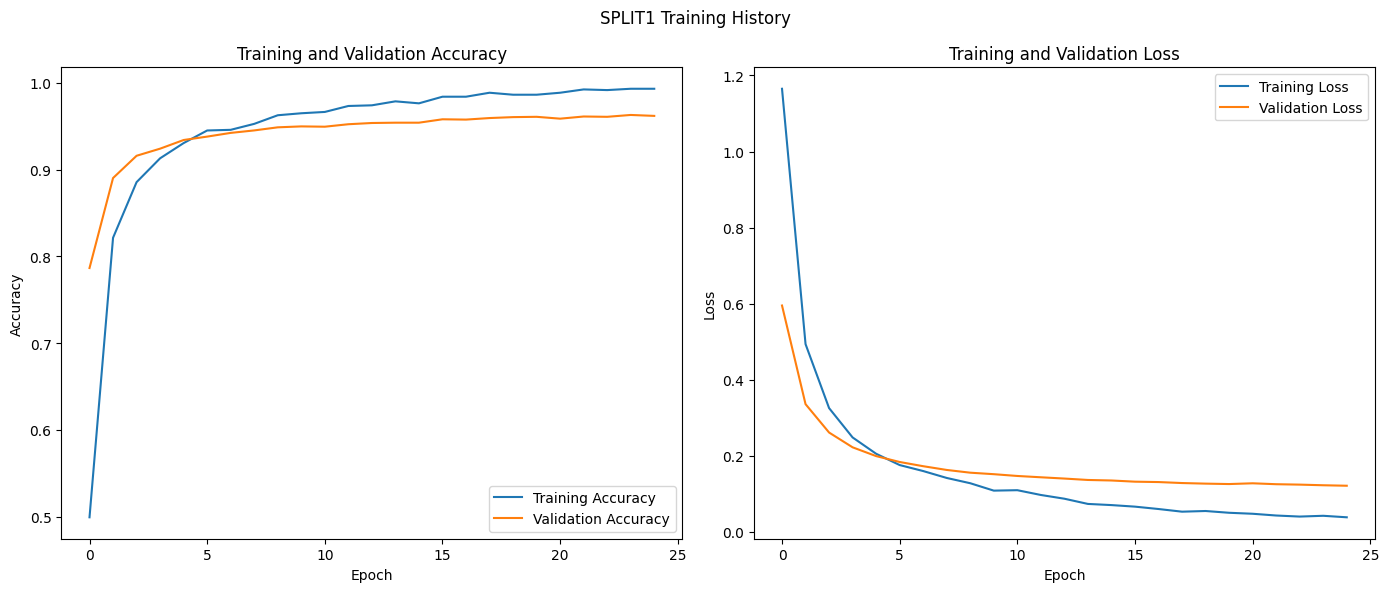

In [56]:
from helper import plot_results

plot_results(history_without_overfit, title="SPLIT1 Training History")

In [40]:
train_gen2, val_gen2 = create_generators(
    train_df=train_df_small2,
    val_df=val_df1,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    use_augmentation=False
)

Found 655 validated image filenames belonging to 4 classes.
Found 2806 validated image filenames belonging to 4 classes.


In [51]:
model1_over_fit=build_model( input_shape=IMG_SIZE + (3,),
    num_classes=NUM_CLASSES,
    learning_rate=LEARNING_RATE,
    dropout_rate=0)

Dropout layer is disabled.


In [52]:
from tensorflow.keras import callbacks
checkpoint_model1_over_fit = callbacks.ModelCheckpoint(
    filepath       = 'MODEL1_V2_over_fit.keras',
    monitor        = 'val_accuracy',
    save_best_only = True,
    mode           = 'max',
    verbose        = 1
)
early_stop2 = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [53]:
history_overfit = model1_over_fit.fit(
    train_gen2,
    epochs=25,
    validation_data=val_gen2,
    callbacks=[checkpoint_model1_over_fit,early_stop2]
)

Epoch 1/25


2026-05-04 22:27:17.886560: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4318', 464 bytes spill stores, 464 bytes spill loads

2026-05-04 22:27:17.929106: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4318', 276 bytes spill stores, 276 bytes spill loads

2026-05-04 22:27:17.954338: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4318', 268 bytes spill stores, 268 bytes spill loads

2026-05-04 22:27:18.033763: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4318', 460 bytes spill stores, 460 bytes spill loads



 3/11 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.2040 - loss: 1.7187

2026-05-04 22:27:19.810332: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1406', 12 bytes spill stores, 12 bytes spill loads

2026-05-04 22:27:19.831323: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1406', 104 bytes spill stores, 104 bytes spill loads

2026-05-04 22:27:19.868725: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1406_0', 176 bytes spill stores, 524 bytes spill loads

2026-05-04 22:27:20.306194: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1406', 5460 bytes spill stores, 5500 bytes spill loads

2026-05-04 22:27:20.382499: I 

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.2635 - loss: 1.6049
Epoch 1: val_accuracy improved from None to 0.55631, saving model to MODEL1_V2_over_fit.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.3405 - loss: 1.4389 - val_accuracy: 0.5563 - val_loss: 1.0097
Epoch 2/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.6427 - loss: 0.9006
Epoch 2: val_accuracy improved from 0.55631 to 0.77619, saving model to MODEL1_V2_over_fit.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 670ms/step - accuracy: 0.6763 - loss: 0.8340 - val_accuracy: 0.7762 - val_loss: 0.6500
Epoch 3/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7884 - loss: 0.6243
Epoch 3: val_accuracy improved from 0.77619 to 0.85103, saving model to MODEL1_V2_over_fit.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 677ms/step - accuracy: 0.8076 - loss: 0.5620 - val_accuracy: 0.8510 - val_loss: 0.4736
Epoch 4/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8736 - loss: 0.4206
Epoch 4: val_accuracy improved

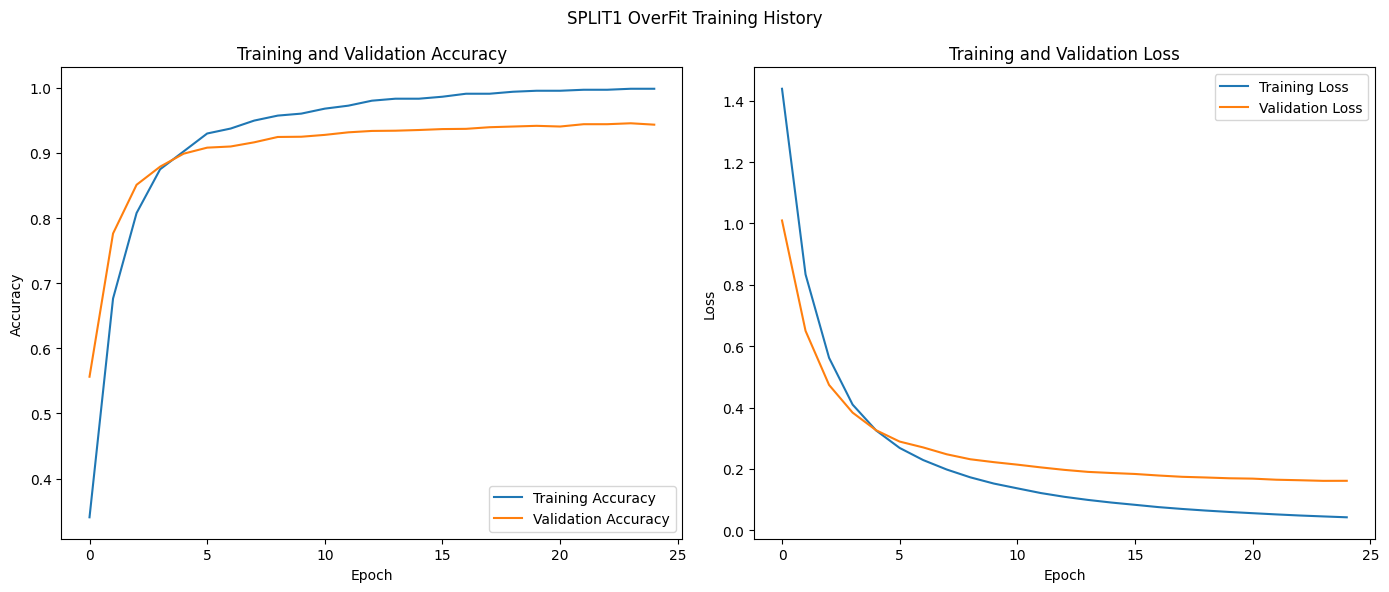

In [55]:
plot_results(history_overfit,title="SPLIT1 OverFit Training History")